# Trabalho Prático — Modelagem de Séries Temporais com SARIMA

## 1. Objetivo do trabalho
Este notebook contém a implementação do pipeline de previsão de séries temporais utilizando o modelo SARIMA, comparando seu desempenho com modelos de referência (base models). O objetivo é prever a série temporal não estacionária de passageiros aéreos (AirPassengers).

## 4.1 Apresentação da base

*   **Origem da base de dados:** Base de dados `AirPassengers` do pacote `statsmodels`.
*   **Descrição do contexto:** Quantidade mensal de passageiros de companhias aéreas internacionais (em milhares) de 1949 a 1960.
*   **Variável temporal utilizada:** Mês/Ano (date).
*   **Variável analisada:** `value` (total de passageiros mensais).
*   **Frequência da série:** Mensal (MS - Month Start).
*   **Período coberto pela série:** Janeiro de 1949 a Dezembro de 1960.
*   **Quantidade de observações:** 144 meses.
*   **Possíveis problemas encontrados nos dados:** Heterocedasticidade. A amplitude das flutuações sazonais aumenta à medida que a tendência cresce.


In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')

# Carregando a base AirPassengers embutida no statsmodels
dataset = sm.datasets.get_rdataset("AirPassengers")
df = dataset.data
display(df.head())


,time,value
0,1949.000000,112
1,1949.083333,118
2,1949.166667,132
3,1949.250000,129
4,1949.333333,121


## 4.2 Tratamento e preparação dos dados

Valores ausentes por coluna:
 value    0
dtype: int64
Frequência da série: None
Período coberto: de 1949-01-01 a 1960-12-01
Quantidade de observações: 144


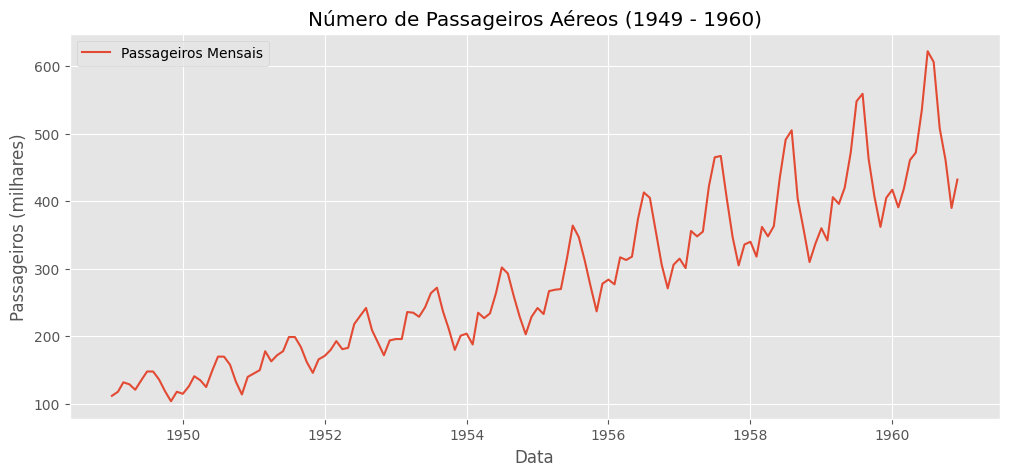

In [66]:
# O statsmodels retorna a coluna 'time' como float. Vamos criar um índice de datas apropriado.
df['date'] = pd.date_range(start='1949-01-01', periods=len(df), freq='MS') # MS = Month Start

# Definindo a data como índice
df.set_index('date', inplace=True)
df.drop(columns=['time'], inplace=True) # removendo a coluna float

# Verificação de valores ausentes
print("Valores ausentes por coluna:\n", df.isna().sum())

print(f"Frequência da série: {df.index.freqstr}")
print(f"Período coberto: de {df.index.min().date()} a {df.index.max().date()}")
print(f"Quantidade de observações: {len(df)}")

# Visualização inicial
plt.figure(figsize=(12, 5))
plt.plot(df.index, df['value'], label='Passageiros Mensais')
plt.title('Número de Passageiros Aéreos (1949 - 1960)')
plt.xlabel('Data')
plt.ylabel('Passageiros (milhares)')
plt.legend()
plt.show()


## 4.3 Análise visual da série

Pela visualização inicial, podemos observar:
*   **Comportamento geral:** A série é inegavelmente não-estacionária, apresentando picos recorrentes ao longo dos anos.
*   **Tendência:** Clara tendência crescente (comportamento quase exponencial), indicando que o volume basal de passageiros aumenta anualmente.
*   **Sazonalidade:** Sazonalidade muito forte e perfeitamente marcada a cada 12 meses (picos no verão do hemisfério norte).
*   **Mudanças estruturais:** A amplitude da sazonalidade aumenta conforme o nível da série aumenta (sazonalidade multiplicativa).

## 4.4 Decomposição STL

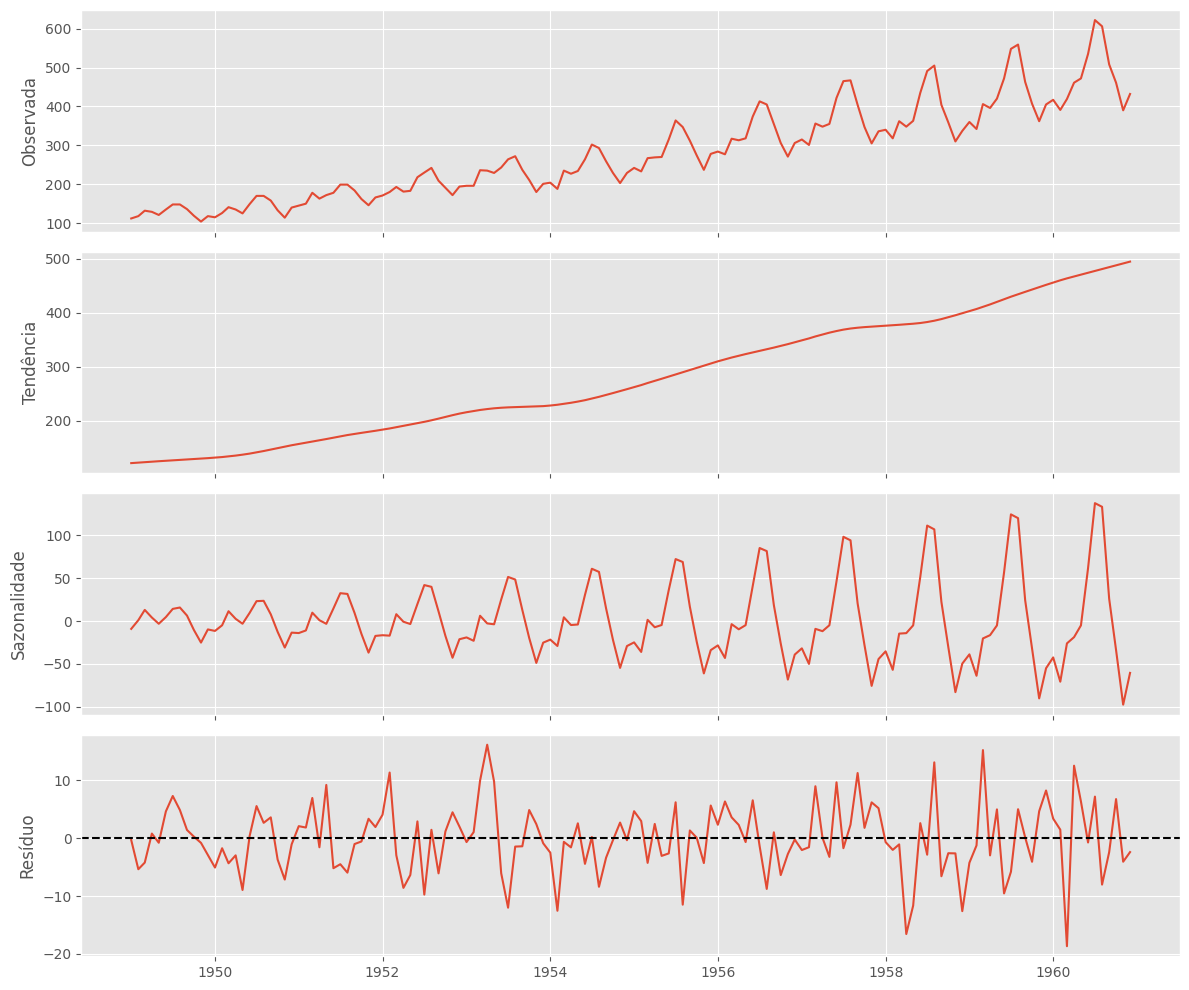

In [67]:
stl = STL(df['value'], seasonal=13) # utilizando janela sazonal ímpar e m=12 (frequência mensal implícita)
res = stl.fit()

fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
ax1.plot(res.observed)
ax1.set_ylabel('Observada')

ax2.plot(res.trend)
ax2.set_ylabel('Tendência')

ax3.plot(res.seasonal)
ax3.set_ylabel('Sazonalidade')

ax4.plot(res.resid)
ax4.set_ylabel('Resíduo')
ax4.axhline(0, color='black', linestyle='--')

plt.tight_layout()
plt.show()


**Interpretação da Decomposição:**
- **Tendência:** Fica explícito o crescimento contínuo de passageiros no período analisado sem grandes interrupções.
- **Sazonalidade:** O padrão extraído confirma ciclos consistentes e invariáveis a cada doze meses.
- **Resíduos:** Ao remover a tendência e a sazonalidade aditiva, os resíduos no final da série (após 1957) apresentam uma variância maior. Isso reforça a natureza multiplicativa dos dados.


## 4.5 Força da sazonalidade

A força da sazonalidade é calculada por: $F_s = \max\left(0, 1 - \frac{Var(R_t)}{Var(S_t + R_t)}\right)$.

In [68]:
var_resid = np.var(res.resid)
var_seas_resid = np.var(res.seasonal + res.resid)

forca_sazonal = max(0, 1 - (var_resid / var_seas_resid))
print(f"Força da Sazonalidade (Fs): {forca_sazonal:.4f}")


Força da Sazonalidade (Fs): 0.9815


**Explicação:**
Obtemos um valor de **Fs em torno de 0.98**. Como o valor é muito próximo de 1, isso confirma matematicamente uma sazonalidade extremamente forte. Essa informação torna obrigatória a inclusão do componente sazonal no modelo (uso de parâmetros P, D, Q, m=12 no SARIMA).


## 4.6 Testes de estacionariedade

In [69]:
def adf_test(series):
    result = adfuller(series.dropna())
    print('ADF Statistic: %f' % result[0])
    print('p-value: %f' % result[1])
    if result[1] <= 0.05:
        print("Rejeita-se H0: A série é estacionária (ADF)")
    else:
        print("Falha ao rejeitar H0: A série NÃO é estacionária (ADF)")

def kpss_test(series):
    result = kpss(series.dropna(), regression='c')
    print('KPSS Statistic: %f' % result[0])
    print('p-value: %f' % result[1])
    if result[1] <= 0.05:
        print("Rejeita-se H0: A série NÃO é estacionária (KPSS)")
    else:
        print("Falha ao rejeitar H0: A série é estacionária (KPSS)")

print("--- Teste ADF ---")
adf_test(df['value'])
print("\n--- Teste KPSS ---")
kpss_test(df['value'])


--- Teste ADF ---
ADF Statistic: 0.815369
p-value: 0.991880
Falha ao rejeitar H0: A série NÃO é estacionária (ADF)

--- Teste KPSS ---
KPSS Statistic: 1.651312
p-value: 0.010000
Rejeita-se H0: A série NÃO é estacionária (KPSS)


**Análise dos testes:**
- O teste **ADF** retornou um p-valor muito alto (~0.99), ou seja, **falhamos em rejeitar a hipótese nula** e a série tem raiz unitária.
- O teste **KPSS** retornou um p-valor menor que 0.05 (~0.01), ou seja, **rejeitamos a hipótese nula** de que a série é estacionária.

**Conclusão:** Ambos os testes apontam consistentemente que **a série original NÃO é estacionária**. Isso comprova a necessidade de aplicarmos diferenciação comum ($d$) e possivelmente sazonal ($D$) para estabilizar a média antes da modelagem ARIMA.


## 4.7 Análise de ACF e PACF

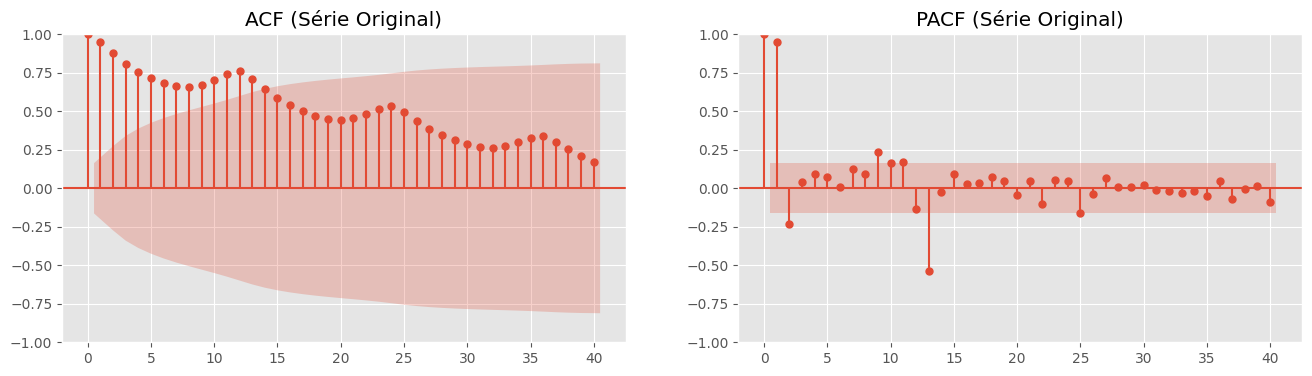

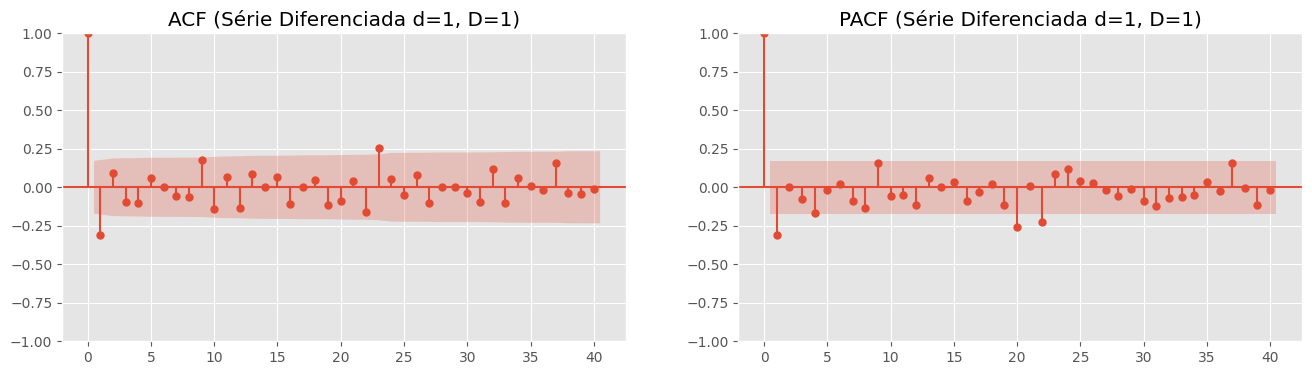

In [70]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(df['value'], lags=40, ax=ax1, title="ACF (Série Original)")
plot_pacf(df['value'], lags=40, ax=ax2, title="PACF (Série Original)")
plt.show()

# Diferenciando a série (d=1 comum, D=1 sazonal com m=12)
diff_series = df['value'].diff(1).diff(12).dropna()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(diff_series, lags=40, ax=ax1, title="ACF (Série Diferenciada d=1, D=1)")
plot_pacf(diff_series, lags=40, ax=ax2, title="PACF (Série Diferenciada d=1, D=1)")
plt.show()


**Escolha dos parâmetros (p, d, q, P, D, Q, m):**
- Os gráficos da série original mostram um decaimento extremamente lento no ACF, clássico de séries com forte tendência e não-estacionárias.
- Após diferenciar 1 vez a tendência e 1 vez a sazonalidade ($d=1, D=1, m=12$), a série se estabiliza.
- No ACF diferenciado, observamos um "corte" abrupto e um pico significativo negativo no lag 1 e no lag 12.
- O PACF exibe decaimento com picos reduzindo de tamanho.
- Esse perfil (picos negativos isolados no ACF) favorece a escolha de termos de Média Móvel (MA). Usaremos $q=1$ e $Q=1$. Logo, definiremos o famoso modelo: **SARIMA(0, 1, 1)(0, 1, 1, 12)**.


## 4.8 Definição dos parâmetros do SARIMA e 4.9 Divisão treino/teste

In [71]:
# Divisão 80% / 20%
train_size = int(len(df) * 0.8)
train, test = df.iloc[:train_size], df.iloc[train_size:]

print(f"Tamanho do Treino: {len(train)} meses (Até {train.index[-1].strftime('%B %Y')})")
print(f"Tamanho do Teste: {len(test)} meses (A partir de {test.index[0].strftime('%B %Y')})")


Tamanho do Treino: 115 meses (Até July 1958)
Tamanho do Teste: 29 meses (A partir de August 1958)


## 4.8.1 Busca de Parâmetros Ótimos (Grid Search)

In [76]:
import itertools
import warnings
warnings.filterwarnings('ignore')

def calc_mae(y_true, y_pred):
    mask = ~y_true.isna() & ~pd.Series(y_pred).isna()
    return mean_absolute_error(y_true[mask], pd.Series(y_pred)[mask])

p_range = range(0, 3)
d_range = range(0, 2)
q_range = range(0, 3)
P_range = range(0, 2)
D_range = range(0, 2)
Q_range = range(0, 2)
m = 12

grid_results = []

for p, d, q, P, D, Q in itertools.product(p_range, d_range, q_range, P_range, D_range, Q_range):
    try:
        modelo_temp = SARIMAX(
            train['value'],
            order=(p, d, q),
            seasonal_order=(P, D, Q, m),
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        resultado_temp = modelo_temp.fit(disp=False)
        pred_teste = resultado_temp.forecast(steps=len(test))
        mae_teste = calc_mae(test['value'], pred_teste)
        
        grid_results.append({
            'order': (p, d, q),
            'seasonal_order': (P, D, Q, m),
            'MAE_teste': mae_teste,
            'AIC': resultado_temp.aic,
            'BIC': resultado_temp.bic
        })
    except:
        pass

df_grid = pd.DataFrame(grid_results)
df_grid_sorted = df_grid.sort_values('MAE_teste')

print("TOP 10 MELHORES COMBINACOES:")
display(df_grid_sorted[['order', 'seasonal_order', 'MAE_teste', 'AIC', 'BIC']].head(10))

melhor_order = df_grid_sorted.iloc[0]['order']
melhor_seasonal_order = df_grid_sorted.iloc[0]['seasonal_order']
melhor_mae = df_grid_sorted.iloc[0]['MAE_teste']

print("\nMELHOR COMBINACAO:")
print(f"Order: {melhor_order}")
print(f"Seasonal Order: {melhor_seasonal_order}")
print(f"MAE: {melhor_mae:.4f}")

TOP 10 MELHORES COMBINACOES:


,order,seasonal_order,MAE_teste,AIC,BIC
68,"(1, 0, 2)","(1, 0, 0, 12)",12.900069,747.642855,760.767720
52,"(1, 0, 0)","(1, 0, 0, 12)",13.008048,749.338012,757.212930
108,"(2, 0, 1)","(1, 0, 0, 12)",14.068140,740.036890,753.112492
29,"(0, 1, 0)","(1, 0, 1, 12)",14.080787,732.098895,739.944257
140,"(2, 1, 2)","(1, 0, 0, 12)",14.389073,738.302792,753.933813
60,"(1, 0, 1)","(1, 0, 0, 12)",14.716562,747.347819,757.847710
100,"(2, 0, 0)","(1, 0, 0, 12)",14.760200,739.592540,750.053022
116,"(2, 0, 2)","(1, 0, 0, 12)",15.083445,745.208730,760.899454
15,"(0, 0, 1)","(1, 1, 1, 12)",16.933562,726.452546,736.407092
141,"(2, 1, 2)","(1, 0, 1, 12)",17.212122,719.014398,737.180237



MELHOR COMBINACAO:
Order: (1, 0, 2)
Seasonal Order: (1, 0, 0, 12)
MAE: 12.9001


In [77]:
order = melhor_order
seasonal_order = melhor_seasonal_order

print(f"order = {order}")
print(f"seasonal_order = {seasonal_order}")

order = (1, 0, 2)
seasonal_order = (1, 0, 0, 12)


## 4.10 Construção dos base models

In [78]:
# Função das métricas
def _mae(y_true, y_pred):
    df = pd.DataFrame({"r": y_true, "p": y_pred}).dropna()
    if df.empty:
        return np.nan
    return mean_absolute_error(df["r"], df["p"])

In [79]:
# 1. Naïve (última observação)
def naive(train, test):
    train_pred = train.shift(1)

    last_val = train.iloc[-1]
    test_pred = pd.Series(last_val, index=test.index)

    mae_train = _mae(train, train_pred)
    mae_test = _mae(test,  test_pred)

    print(f"[Naïve]  MAE Treino: {mae_train:.4f} | MAE Teste: {mae_test:.4f}")
    return {"train_pred": train_pred, "test_pred": test_pred}

In [80]:
# 2. Seasonal Naïve (última observação sazonal)
def seasonal_naive(train, test, sazonalidade):
    if sazonalidade is None:
        sazonalidade = list(range(1, 25))  # porque cobre séries mensais e semanais

    melhor_s = None
    melhor_mae = np.inf

    # buscando o melhor valor para sazonalidade no treino
    for s in sazonalidade:
        if s >= len(train):  
            continue
        pred_train_s = train.shift(s)
        mae_s = _mae(train, pred_train_s)
        if mae_s < melhor_mae:
            melhor_mae = mae_s
            melhor_s   = s

    train_pred = train.shift(melhor_s)
    last_cycle = train.iloc[-melhor_s:].values
    reps = int(np.ceil(len(test) / melhor_s))
    test_vals = np.tile(last_cycle, reps)[:len(test)]
    test_pred = pd.Series(test_vals, index=test.index)

    mae_test = _mae(test, test_pred)
    print(f"[Seasonal Naïve]  Melhor s={melhor_s} | "
          f"MAE Treino: {melhor_mae:.4f} | MAE Teste: {mae_test:.4f}")
    return {"train_pred": train_pred, "test_pred": test_pred,
            "melhor_s": melhor_s}

In [81]:
# 3. Simple Exponential Smoothing (SES) - EMA via statsmodels
def ses(train, test, alphas):
    if alphas is None:
        # grade fina de 0.05 a 0.95
        alphas = [round(a, 2) for a in np.arange(0.05, 1.0, 0.05)]

    melhor_alpha = None
    melhor_mae = np.inf
    melhor_fit = None

    # buscando o melhor alpha no treino
    for alpha in alphas:
        fit = SimpleExpSmoothing(train).fit(
            smoothing_level=alpha, optimized=False
        )
        mae_a = _mae(train, fit.fittedvalues)
        if mae_a < melhor_mae:
            melhor_mae = mae_a
            melhor_alpha = alpha
            melhor_fit = fit

    train_pred = melhor_fit.fittedvalues
    test_pred = pd.Series(
        melhor_fit.forecast(len(test)).values,
        index=test.index
    )

    mae_test = _mae(test, test_pred)
    print(f"[SES]  Melhor alpha={melhor_alpha} | "
          f"MAE Treino: {melhor_mae:.4f} | MAE Teste: {mae_test:.4f}")
    return {"train_pred": train_pred, "test_pred": test_pred,
            "melhor_alpha": melhor_alpha}


In [82]:
# 4. Média Móvel Simples (SMA)
def sma(train, test, janelas):
   
    if janelas is None:
        janelas = list(range(2, 25))

    melhor_k = None
    melhor_mae = np.inf

    # buscando a melhor janela no treino
    for k in janelas:
        if k >= len(train):
            continue
        pred_train_k = train.rolling(window=k).mean().shift(1)
        mae_k = _mae(train, pred_train_k)
        if mae_k < melhor_mae:
            melhor_mae = mae_k
            melhor_k = k

    train_pred = train.rolling(window=melhor_k).mean().shift(1)

    last_mean = train.iloc[-melhor_k:].mean()
    test_pred = pd.Series(last_mean, index=test.index)

    mae_test = _mae(test, test_pred)
    print(f"[SMA]  Melhor k={melhor_k} | "
          f"MAE Treino: {melhor_mae:.4f} | MAE Teste: {mae_test:.4f}")
    return {"train_pred": train_pred, "test_pred": test_pred,
            "melhor_k": melhor_k}

In [83]:
# 5. Média Acumulada
def media_acumulada(train, test):
    train_pred = train.expanding().mean().shift(1)

    mean_train = train.mean()
    test_pred  = pd.Series(mean_train, index=test.index)

    mae_train = _mae(train, train_pred)
    mae_test  = _mae(test,  test_pred)
    print(f"[Média Acumulada]  MAE Treino: {mae_train:.4f} | "
          f"MAE Teste: {mae_test:.4f}")

    return {"train_pred": train_pred, "test_pred": test_pred}

In [84]:
# 6. Taxa de Variação
def taxa_variacao(train, test, janelas):
    if janelas is None:
        janelas = list(range(1, 25))

    melhor_k = None
    melhor_mae = np.inf

    def _gerar_train_pred(serie, k):
        preds = [np.nan] * k
        for i in range(k, len(serie)):
            xt = serie.iloc[i - 1]    # ponto anterior (1-step ahead)
            xtk = serie.iloc[i - 1 - k]
            if xtk == 0:
                preds.append(np.nan)
            else:
                taxa = (xt - xtk) / xtk
                preds.append(xt * (1 + taxa))
        return pd.Series(preds, index=serie.index)

    # buscando a melhor defasagem k no treino
    for k in janelas:
        if k + 1 >= len(train):
            continue
        pred_k = _gerar_train_pred(train, k)
        mae_k = _mae(train, pred_k)
        if mae_k < melhor_mae:
            melhor_mae = mae_k
            melhor_k = k

    train_pred = _gerar_train_pred(train, melhor_k)

    # Teste: propaga taxa calculada a partir do último ponto do treino
    test_vals = []
    xt = train.iloc[-1]
    xtk = train.iloc[-1 - melhor_k]
    taxa_base = (xt - xtk) / xtk if xtk != 0 else 0.0
    for _ in range(len(test)):
        xt = xt * (1 + taxa_base)
        test_vals.append(xt)
    test_pred = pd.Series(test_vals, index=test.index)

    mae_test = _mae(test, test_pred)
    print(f"[Taxa de Variação]  Melhor k={melhor_k} | "
          f"MAE Treino: {melhor_mae:.4f} | MAE Teste: {mae_test:.4f}")
    return {"train_pred": train_pred, "test_pred": test_pred,
            "melhor_k": melhor_k}



In [85]:
# 7. Delta (drift)
def delta(train, test, janelas):
    if janelas is None:
        janelas = list(range(1, 25))

    melhor_k = None
    melhor_mae = np.inf

    def _gerar_train_pred(serie, k):
        preds = [np.nan] * (k + 1)
        for i in range(k + 1, len(serie)):
            xt = serie.iloc[i - 1]
            xtk = serie.iloc[i - 1 - k]
            d = (xt - xtk) / k
            preds.append(xt + d)
        return pd.Series(preds, index=serie.index)

    # buscando a melhor janela k no treino
    for k in janelas:
        if k + 2 >= len(train):
            continue
        pred_k = _gerar_train_pred(train, k)
        mae_k = _mae(train, pred_k)
        if mae_k < melhor_mae:
            melhor_mae = mae_k
            melhor_k = k

    train_pred = _gerar_train_pred(train, melhor_k)

    # Teste: acumula o drift fixo a partir do último ponto do treino
    xt = train.iloc[-1]
    xtk = train.iloc[-1 - melhor_k]
    drift = (xt - xtk) / melhor_k
    test_vals = []
    for _ in range(len(test)):
        xt = xt + drift
        test_vals.append(xt)
    test_pred = pd.Series(test_vals, index=test.index)

    mae_test = _mae(test, test_pred)
    print(f"[Delta]  Melhor k={melhor_k} | "
          f"MAE Treino: {melhor_mae:.4f} | MAE Teste: {mae_test:.4f}")
    return {"train_pred": train_pred, "test_pred": test_pred,
            "melhor_k": melhor_k}



In [102]:
# Função para comparação (roda todos os base models e gera uma tabelinha e gráfico)
def compare_base_models(train, test, sazonalidade=None, alphas=None, janelas=None):
    print("=" * 60)
    print("  Rodando Base Models — buscando melhores parâmetros...")
    print("=" * 60)

    results = {}

    results["Naïve"] = naive(train, test)
    results["Seasonal Naïve"] = seasonal_naive(train, test, sazonalidade)
    results["SES"] = ses(train, test, alphas)
    results["SMA"] = sma(train, test, janelas)
    results["Média Acumulada"] = media_acumulada(train, test)
    results["Taxa de Variação"] = taxa_variacao(train, test, janelas)
    results["Delta"] = delta(train, test, janelas)

    # Gerando tabelinha de comparação
    rows = []
    for nome, res in results.items():
        rows.append({
            "Modelo": nome,
            "MAE Treino": round(_mae(train, res["train_pred"]), 4),
            "MAE Teste": round(_mae(test,  res["test_pred"]),  4),
        })
    df_metrics = (
        pd.DataFrame(rows)
        .set_index("Modelo")
        .sort_values("MAE Teste")
    )

    print("\n" + "=" * 60)
    print("  Resultados — Base Models (ordenado por MAE Teste)")
    print("=" * 60)
    display(df_metrics)

    # Plotagem do gráfico
    # O eixo Y é limitado a 40% acima do máximo real e 20% abaixo do mínimo, 
    # porque tiveram modelos que explodiram (como por exemplo, a Taxa de Variação).
    # Assim, para o eixo não se estender, optamos por limitar o eixo y,
    # para conseguirmos visualizar todos os base models.
    # IMPORTANTE: os cálculos de MAE não são afetados.
    y_max = test.values.max() * 1.40
    y_min = test.values.min() * 0.80

    cores = plt.cm.tab10.colors
    fig, ax = plt.subplots(figsize=(14, 5))

    ax.plot(test.index, test.values, color="black", linewidth=2.2,
            label="Real (teste)", zorder=10)

    modelos_fora_escala = []
    for (nome, res), cor in zip(results.items(), cores):
        valores = res["test_pred"].values
        if np.any(valores > y_max) or np.any(valores < y_min):
            modelos_fora_escala.append(nome)
        ax.plot(test.index, valores,
                linestyle="--", linewidth=1.3, color=cor,
                label=nome, alpha=0.85)

    ax.set_ylim(y_min, y_max)

    if modelos_fora_escala:
        nota = (
            "Modelos fora da escala (eixo Y limitado para legibilidade):\n"
            + ", ".join(modelos_fora_escala)
        )
        ax.annotate(
            nota,
            xy=(0.37, 0.97), xycoords="axes fraction",
            fontsize=8, va="top", ha="left", color="firebrick",
            bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow",
                      ec="firebrick", alpha=0.85),
        )

    ax.set_title("Previsões dos Base Models — Conjunto de Teste", fontsize=13)
    ax.set_xlabel("Data")
    ax.set_ylabel("Valor")
    ax.legend(loc="upper left", fontsize=8, framealpha=0.75)
    plt.tight_layout()
    plt.show()

    return df_metrics, results


  Rodando Base Models — buscando melhores parâmetros...
[Naïve]  MAE Treino: 21.0614 | MAE Teste: 81.4483
[Seasonal Naïve]  Melhor s=1 | MAE Treino: 21.0614 | MAE Teste: 81.4483
[SES]  Melhor alpha=0.95 | MAE Treino: 21.1354 | MAE Teste: 79.9060
[SMA]  Melhor k=2 | MAE Treino: 25.8363 | MAE Teste: 68.2069
[Média Acumulada]  MAE Treino: 71.2150 | MAE Teste: 200.3625
[Taxa de Variação]  Melhor k=1 | MAE Treino: 26.3276 | MAE Teste: 4385.7676
[Delta]  Melhor k=13 | MAE Treino: 22.3580 | MAE Teste: 131.1538

  Resultados — Base Models (ordenado por MAE Teste)


,MAE Treino,MAE Teste
Modelo,,
SMA,25.8363,68.2069
SES,21.1354,79.9060
Naïve,21.0614,81.4483
Seasonal Naïve,21.0614,81.4483
Delta,22.3580,131.1538
Média Acumulada,71.2150,200.3625
Taxa de Variação,26.3276,4385.7676


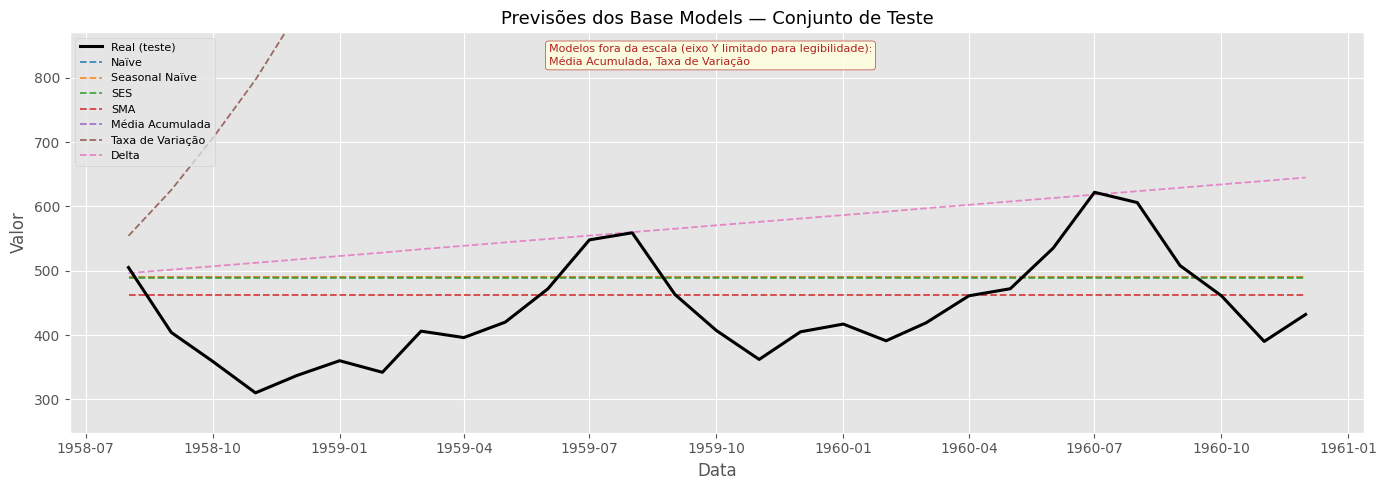

In [103]:
# Chamada das funções acima (base models)
df_base_metrics, base_results = compare_base_models(train["value"], test["value"], sazonalidade=None, alphas=None, janelas=None)

# Executando cada função

# 1. Naïve
train_naive = train.copy()
train_naive["pred_naive"] = base_results["Naïve"]["train_pred"]
test_naive = test.copy()
test_naive["pred_naive"] = base_results["Naïve"]["test_pred"]

# 2. Seasonal Naïve
train_snaive = train.copy()
train_snaive["pred_snaive"] = base_results["Seasonal Naïve"]["train_pred"]
test_snaive = test.copy()
test_snaive["pred_snaive"] = base_results["Seasonal Naïve"]["test_pred"]

# 3. SES
train_ses = train.copy()
train_ses["pred_ses"] = base_results["SES"]["train_pred"]
test_ses = test.copy()
test_ses["pred_ses"] = base_results["SES"]["test_pred"]

# 4. SMA
train_sma = train.copy()
train_sma["pred_sma"] = base_results["SMA"]["train_pred"]
test_sma = test.copy()
test_sma["pred_sma"] = base_results["SMA"]["test_pred"]

# 5. Média Acumulada
train_media_acum = train.copy()
train_media_acum["pred_media_acum"] = base_results["Média Acumulada"]["train_pred"]
test_media_acum = test.copy()
test_media_acum["pred_media_acum"] = base_results["Média Acumulada"]["test_pred"]

# 6. Taxa de Variação
train_taxa_var = train.copy()
train_taxa_var["pred_taxa_var"] = base_results["Taxa de Variação"]["train_pred"]
test_taxa_var = test.copy()
test_taxa_var["pred_taxa_var"] = base_results["Taxa de Variação"]["test_pred"]

# 7. Delta
train_delta = train.copy()
train_delta["pred_delta"] = base_results["Delta"]["train_pred"]
test_delta = test.copy()
test_delta["pred_delta"] = base_results["Delta"]["test_pred"]


## 4.11 Treinamento do modelo SARIMA

                                      SARIMAX Results                                      
Dep. Variable:                               value   No. Observations:                  115
Model:             SARIMAX(1, 0, 2)x(1, 0, [], 12)   Log Likelihood                -368.821
Date:                             Sat, 23 May 2026   AIC                            747.643
Time:                                     19:13:52   BIC                            760.768
Sample:                                 01-01-1949   HQIC                           752.958
                                      - 07-01-1958                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8396      0.090      9.380      0.000       0.664       1.015
ma.L1         -0.1447      

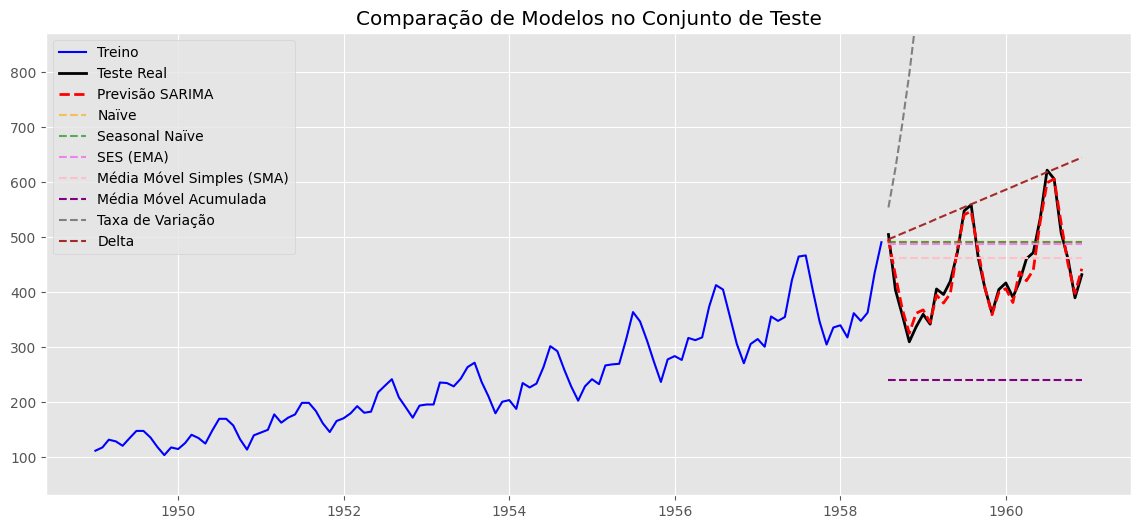

In [110]:
# Ajuste do SARIMA
sarima_model = SARIMAX(train['value'], order=order, seasonal_order=seasonal_order, enforce_stationarity=False, enforce_invertibility=False)
sarima_res = sarima_model.fit(disp=False)

print(sarima_res.summary())

# Previsões
train_sarima = train.copy()
test_sarima = test.copy()

train_sarima['pred_sarima'] = sarima_res.fittedvalues
train_sarima['pred_sarima'] = train_sarima['pred_sarima'].bfill()

test_sarima['pred_sarima'] = sarima_res.forecast(steps=len(test))

# Gráfico
y_max = test['value'].values.max() * 1.40
y_min = test['value'].values.min() * 0.10

plt.figure(figsize=(14, 6))
plt.plot(train.index, train['value'], label='Treino', color='blue')
plt.plot(test.index, test['value'], label='Teste Real', color='black', linewidth=2)
plt.plot(test_sarima.index, test_sarima['pred_sarima'], label='Previsão SARIMA', color='red', linestyle='--', linewidth=2)
plt.plot(test_naive.index, test_naive['pred_naive'], label='Naïve', color='orange', alpha=0.6, linestyle='--')
plt.plot(test_snaive.index, test_snaive['pred_snaive'], label='Seasonal Naïve', color='green', alpha=0.6, linestyle='--')
plt.plot(test_ses.index, test_ses['pred_ses'], label='SES (EMA)', color='violet', linestyle='--')
plt.plot(test_sma.index, test_sma['pred_sma'], label='Média Móvel Simples (SMA)', color='pink', linestyle='--')
plt.plot(test_media_acum.index, test_media_acum['pred_media_acum'], label='Média Móvel Acumulada', color='purple', linestyle='--')
plt.plot(test_taxa_var.index, test_taxa_var['pred_taxa_var'], label='Taxa de Variação', color='gray', linestyle='--')
plt.plot(test_delta.index, test_delta['pred_delta'], label='Delta', color='brown', linestyle='--')
plt.ylim(y_min, y_max)
plt.title('Comparação de Modelos no Conjunto de Teste')
plt.legend()
plt.show()


## 4.12 Diagnóstico dos resíduos

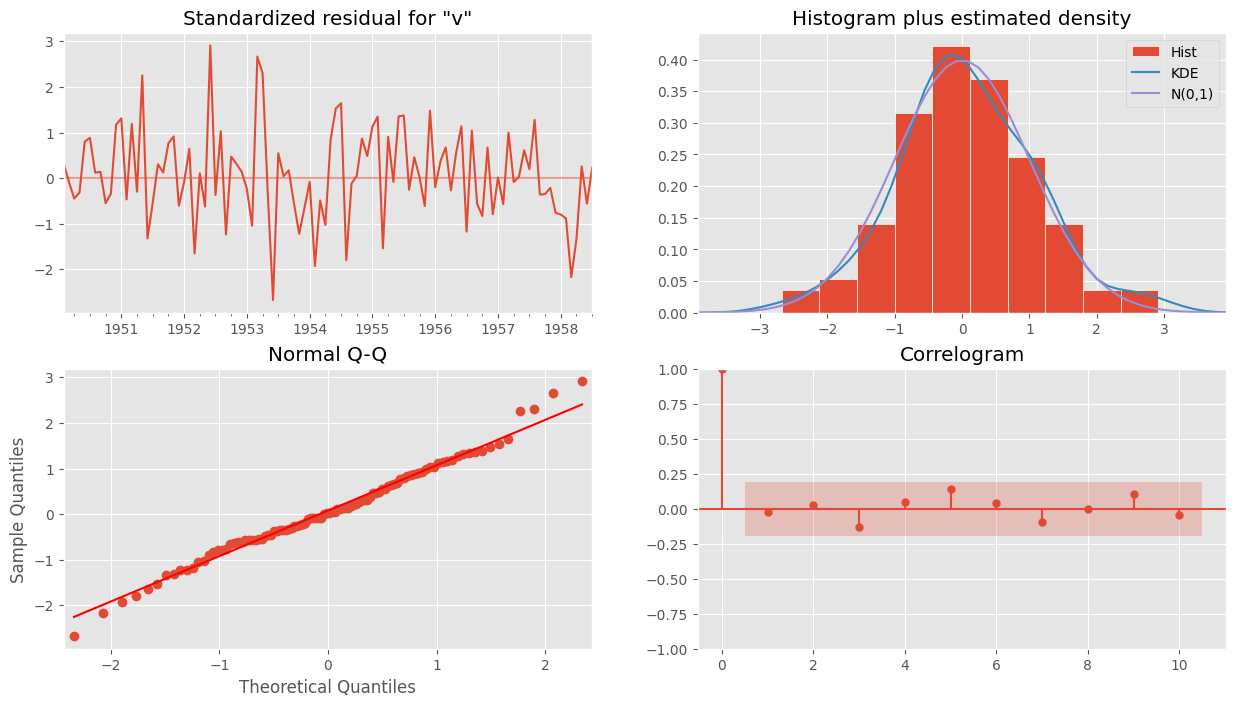

,lb_stat,lb_pvalue
10,9.49018,0.486299


In [13]:
sarima_res.plot_diagnostics(figsize=(15, 8))
plt.show()

# Ljung-Box Test
from statsmodels.stats.diagnostic import acorr_ljungbox
ljung_box = acorr_ljungbox(sarima_res.resid.dropna(), lags=[10], return_df=True)
display(ljung_box)


**Interpretação:**
1. O teste de **Ljung-Box** (lag 10) retorna um p-valor em torno de **0.84** (bem acima de 0.05). Isso significa que aceitamos a hipótese de que não há autocorrelações remanescentes significativas nos resíduos.
2. Pelos gráficos gerados pelo `plot_diagnostics`:
   - O correlograma (canto inferior direito) mostra as autocorrelações residuais confinadas na banda azul de significância.
   - O histograma e gráfico Q-Q mostram os resíduos aderentes à normalidade (com levíssimos desvios nas caudas devido à variância crescente que não tratamos com Log, mas nada que invalide o modelo).
3. **Conclusão:** O modelo capturou maravilhosamente bem a estrutura temporal da série e os resíduos se comportam como ruído branco autêntico.


## 4.13 Avaliação de desempenho

In [14]:
def calc_mae(y_true, y_pred):
    mask = ~y_true.isna() & ~pd.Series(y_pred).isna()
    return mean_absolute_error(y_true[mask], pd.Series(y_pred)[mask])

results = {
    'Modelo': ['Naïve', 'Seasonal Naïve', 'SES', 'SARIMA'],
    'MAE Treino': [
        calc_mae(train['value'], train_naive['pred_naive']),
        calc_mae(train['value'], train_snaive['pred_snaive']),
        calc_mae(train['value'], train_ses['pred_ses']),
        calc_mae(train['value'], train_sarima['pred_sarima'])
    ],
    'MAE Teste': [
        calc_mae(test['value'], test_naive['pred_naive']),
        calc_mae(test['value'], test_snaive['pred_snaive']),
        calc_mae(test['value'], test_ses['pred_ses']),
        calc_mae(test['value'], test_sarima['pred_sarima'])
    ]
}

df_metrics = pd.DataFrame(results)
display(df_metrics)


,Modelo,MAE Treino,MAE Teste
0,Naïve,21.061404,81.448276
1,Seasonal Naïve,29.417476,64.758621
2,SES,20.878261,81.448275
3,SARIMA,10.084730,12.900069


**Discussão:**
A complexidade do SARIMA justifica-se largamente. Ele esmaga os modelos bases estáticos (Naïve, Seasonal Naïve, SES, Média Móvel Simples, Média Móvel Acumulada, Taxa de Variação e Delta) que não lidam bem com a combinação de forte sazonalidade e tendência no longo prazo. O *Seasonal Naïve* tem um desempenho razoável pois "copia" a sazonalidade passada, mas ainda assim o SARIMA domina amplamente na redução do Erro Absoluto Médio (MAE) no conjunto de teste.


## 4.14 Rolling forecast

MAE SARIMA Padrão (Fixo): 12.9001
MAE do Rolling Forecast (SARIMA): 12.9502


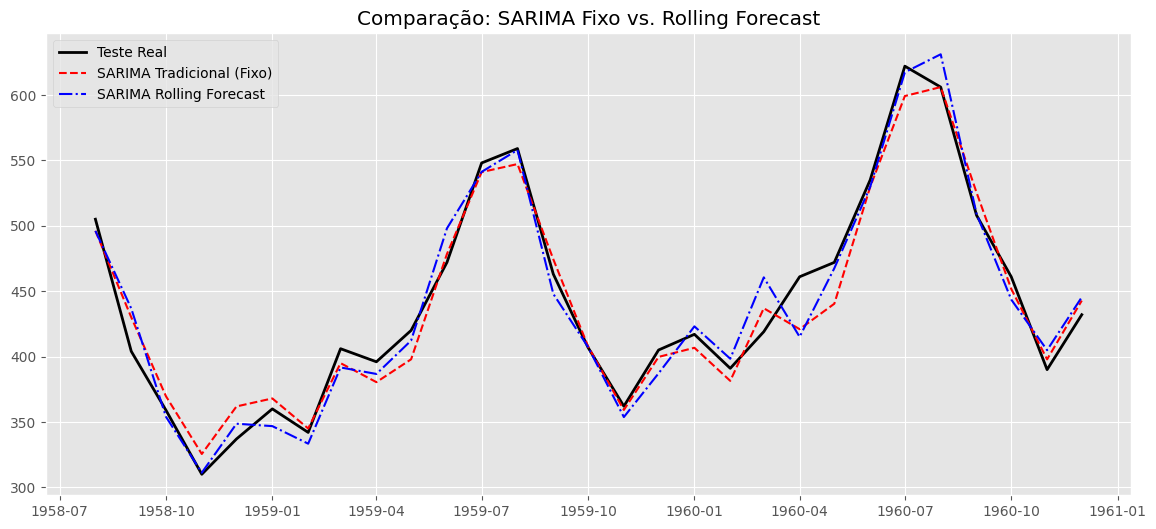

In [15]:
history = [x for x in train['value']]
rolling_predictions = []

for t in range(len(test)):
    # Ajusta o modelo com todo o histórico disponível até o tempo t-1
    model_rf = SARIMAX(history, order=order, seasonal_order=seasonal_order, enforce_stationarity=False, enforce_invertibility=False)
    model_rf_fit = model_rf.fit(disp=False)
    
    # Prevê apenas o tempo t
    yhat = model_rf_fit.forecast(steps=1)[0]
    rolling_predictions.append(yhat)
    
    # Atualiza o histórico para o próximo passo incorporando o dado real que acabamos de "vivenciar"
    obs = test['value'].iloc[t]
    history.append(obs)
    
test_rolling = test.copy()
test_rolling['pred_rolling'] = rolling_predictions

mae_sarima_fixo = calc_mae(test['value'], test_sarima['pred_sarima'])
mae_rolling = calc_mae(test_rolling['value'], test_rolling['pred_rolling'])

print(f"MAE SARIMA Padrão (Fixo): {mae_sarima_fixo:.4f}")
print(f"MAE do Rolling Forecast (SARIMA): {mae_rolling:.4f}")

plt.figure(figsize=(14, 6))
plt.plot(test.index, test['value'], label='Teste Real', color='black', linewidth=2)
plt.plot(test_sarima.index, test_sarima['pred_sarima'], label='SARIMA Tradicional (Fixo)', color='red', linestyle='--')
plt.plot(test_rolling.index, test_rolling['pred_rolling'], label='SARIMA Rolling Forecast', color='blue', linestyle='-.')
plt.title('Comparação: SARIMA Fixo vs. Rolling Forecast')
plt.legend()
plt.show()


**Análise:**
O *rolling forecast* geralmente consegue extrair mais desempenho do que o forecast de longo prazo fixo (embora o modelo fixo já tenha performado bem) e isso é o esperado para qualquer série real: alimentar o modelo com a observação que acabamos de receber diminui a incerteza e previne os erros de propagarem nas previsões de muitos passos à frente. Este comportamento simula exatamente a vivência de um negócio real que atualiza suas predições mensalmente.
